# Notebook 03: Bellman Equations

**Series:** Reinforcement Learning Basics (3/20)

---

## 1. Why Bellman Equations?

Bellman equations are the **foundation of all RL algorithms**. They express a recursive relationship:

> *"The value of a state equals the immediate reward plus the discounted value of the next state."*

This recursive structure lets us:
- **Solve** for value functions (DP)
- **Estimate** value functions (MC, TD)
- **Optimize** policies (Q-learning, Policy Gradient)

## 2. Bellman Expectation Equation for $V^\pi$

### Derivation

Starting from the definition:
$$V^\pi(s) = \mathbb{E}_\pi[G_t | S_t = s]$$

Expand $G_t$:
$$= \mathbb{E}_\pi[R_{t+1} + \gamma G_{t+1} | S_t = s]$$

$$= \mathbb{E}_\pi[R_{t+1} | S_t = s] + \gamma \, \mathbb{E}_\pi[G_{t+1} | S_t = s]$$

Condition on action and next state:

$$\boxed{V^\pi(s) = \sum_{a} \pi(a|s) \sum_{s'} P(s'|s,a) \Big[ R(s,a,s') + \gamma \, V^\pi(s') \Big]}$$

**In words:** Value of $s$ = weighted average over actions of (expected immediate reward + discounted value of next state).

## 3. Bellman Expectation Equation for $Q^\pi$

$$\boxed{Q^\pi(s,a) = \sum_{s'} P(s'|s,a) \Big[ R(s,a,s') + \gamma \sum_{a'} \pi(a'|s') Q^\pi(s',a') \Big]}$$

## 4. Bellman Optimality Equations

For the **optimal** value functions:

$$\boxed{V^*(s) = \max_a \sum_{s'} P(s'|s,a) \Big[ R(s,a,s') + \gamma \, V^*(s') \Big]}$$

$$\boxed{Q^*(s,a) = \sum_{s'} P(s'|s,a) \Big[ R(s,a,s') + \gamma \max_{a'} Q^*(s',a') \Big]}$$

**Key difference:** Expectation equations average over $\pi$; Optimality equations take the **max** over actions.

## 5. Matrix Form

For a fixed policy $\pi$, the Bellman equation is **linear**:

$$\mathbf{v}^\pi = \mathbf{r}^\pi + \gamma \mathbf{P}^\pi \mathbf{v}^\pi$$

where:
- $\mathbf{v}^\pi \in \mathbb{R}^{|\mathcal{S}|}$ is the value vector
- $\mathbf{P}^\pi_{ss'} = \sum_a \pi(a|s) P(s'|s,a)$ is the transition matrix under $\pi$
- $\mathbf{r}^\pi_s = \sum_a \pi(a|s) \sum_{s'} P(s'|s,a) R(s,a,s')$

**Closed-form solution:**
$$\mathbf{v}^\pi = (\mathbf{I} - \gamma \mathbf{P}^\pi)^{-1} \mathbf{r}^\pi$$

**Complexity:** $O(|\mathcal{S}|^3)$ for matrix inversion — only feasible for small MDPs.

## 6. Contraction Mapping (Intuition)

The **Bellman operator** $T^\pi$ defined by:
$$(T^\pi V)(s) = \sum_a \pi(a|s) \sum_{s'} P(s'|s,a)[R(s,a,s') + \gamma V(s')]$$

is a **$\gamma$-contraction** in the max-norm:
$$\| T^\pi V_1 - T^\pi V_2 \|_\infty \leq \gamma \| V_1 - V_2 \|_\infty$$

By the **Banach Fixed-Point Theorem**, $T^\pi$ has a unique fixed point $V^\pi$, and repeated application converges:
$$V_0 \xrightarrow{T^\pi} V_1 \xrightarrow{T^\pi} V_2 \xrightarrow{T^\pi} \cdots \to V^\pi$$

<>:61: SyntaxWarning: invalid escape sequence '\p'
<>:61: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Milan Amrut Joshi\AppData\Local\Temp\ipykernel_58284\3398307485.py:61: SyntaxWarning: invalid escape sequence '\p'
  ax.set_title('$V^\pi$ for Random Policy (Bellman Exact Solution)', fontsize=14)


Exact V^pi (uniform random policy, gamma=1.0):
[[ -0.  -11.9 -17.  -18.6]
 [-11.9 -15.3 -17.  -17. ]
 [-17.  -17.  -15.3 -11.9]
 [-18.6 -17.  -11.9   0. ]]



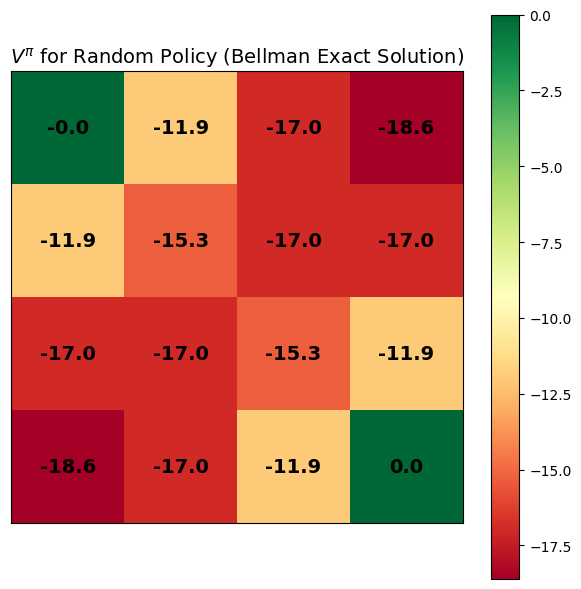

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Solving Bellman Equations via Matrix Inversion
# ============================================

# 4x4 GridWorld MDP
size = 4
n_states = size * size
n_actions = 4  # up, right, down, left
gamma = 0.99  # Use 0.99 to avoid singular matrix with terminal absorbing states
terminal_states = [0, 15]

# Build transition model
P = np.zeros((n_states, n_actions, n_states))
R = np.zeros((n_states, n_actions, n_states))

moves = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}

for s in range(n_states):
    if s in terminal_states:
        for a in range(n_actions):
            P[s, a, s] = 1.0
            R[s, a, s] = 0.0
        continue
    row, col = divmod(s, size)
    for a in range(n_actions):
        dr, dc = moves[a]
        new_row = max(0, min(size-1, row + dr))
        new_col = max(0, min(size-1, col + dc))
        s_next = new_row * size + new_col
        P[s, a, s_next] = 1.0
        R[s, a, s_next] = -1.0

# Uniform random policy
pi = np.ones((n_states, n_actions)) / n_actions

# Build P^pi and r^pi
P_pi = np.zeros((n_states, n_states))
r_pi = np.zeros(n_states)
for s in range(n_states):
    for a in range(n_actions):
        P_pi[s] += pi[s, a] * P[s, a]
        r_pi[s] += pi[s, a] * np.sum(P[s, a] * R[s, a])

# Solve: v = (I - gamma * P_pi)^{-1} * r_pi
V_exact = np.linalg.solve(np.eye(n_states) - gamma * P_pi, r_pi)

print("Exact V^pi (uniform random policy, gamma=1.0):")
print(V_exact.reshape(size, size).round(1))
print()

# Visualize
fig, ax = plt.subplots(figsize=(6, 6))
V_grid = V_exact.reshape(size, size)
im = ax.imshow(V_grid, cmap='RdYlGn')
for i in range(size):
    for j in range(size):
        ax.text(j, i, f'{V_grid[i,j]:.1f}', ha='center', va='center', fontsize=14, fontweight='bold')
ax.set_title('$V^\pi$ for Random Policy (Bellman Exact Solution)', fontsize=14)
ax.set_xticks([])
ax.set_yticks([])
plt.colorbar(im)
plt.tight_layout()
plt.show()

## Summary

| Equation | Formula |
|----------|---------|
| **Bellman Expectation (V)** | $V^\pi(s) = \sum_a \pi(a|s) \sum_{s'} P(s'|s,a)[R + \gamma V^\pi(s')]$ |
| **Bellman Expectation (Q)** | $Q^\pi(s,a) = \sum_{s'} P(s'|s,a)[R + \gamma \sum_{a'} \pi(a'|s') Q^\pi(s',a')]$ |
| **Bellman Optimality (V)** | $V^*(s) = \max_a \sum_{s'} P(s'|s,a)[R + \gamma V^*(s')]$ |
| **Bellman Optimality (Q)** | $Q^*(s,a) = \sum_{s'} P(s'|s,a)[R + \gamma \max_{a'} Q^*(s',a')]$ |
| **Matrix Form** | $\mathbf{v}^\pi = (I - \gamma P^\pi)^{-1} \mathbf{r}^\pi$ |

**Next:** Notebook 04 — Dynamic Programming